In [8]:
!pip install imbalanced-learn -q

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.style.use('seaborn-v0_8-whitegrid')
PAL = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#00BCD4','#FF5722','#607D8B','#795548']
print('Libraries loaded')

Libraries loaded


In [10]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
df.head()

Shape   : (7043, 21)
Columns : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')
print(f'\nChurn distribution:\n{df["Churn"].value_counts()}')

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicates: 0

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print(f'Churn rate: {df["Churn"].mean():.2%}')
print(f'TotalCharges nulls after fix: {df["TotalCharges"].isnull().sum()}')

Churn rate: 26.54%
TotalCharges nulls after fix: 0


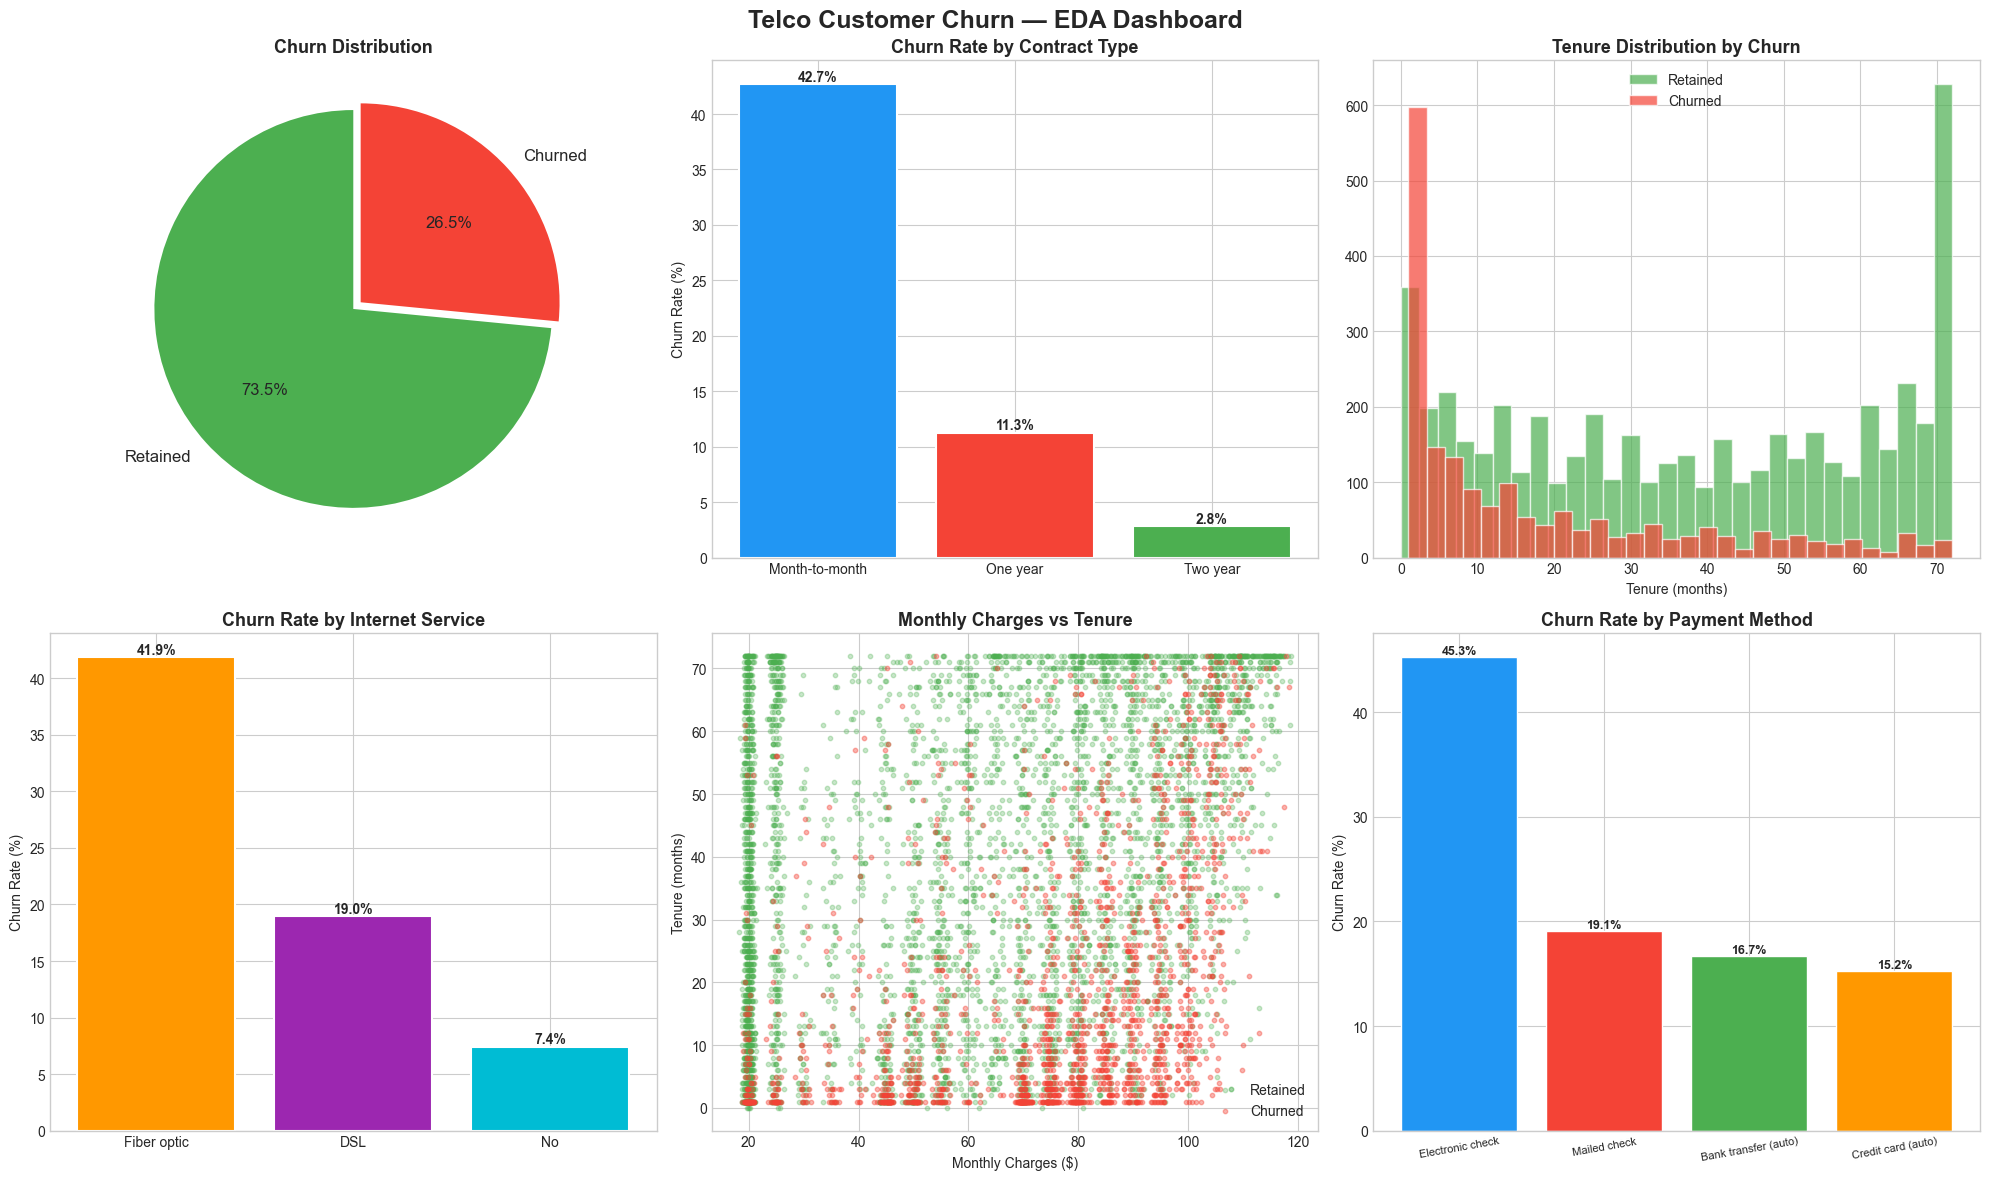

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Telco Customer Churn — EDA Dashboard', fontsize=18, fontweight='bold')

cv = df['Churn'].value_counts()
axes[0,0].pie(cv, labels=['Retained','Churned'], autopct='%1.1f%%',
              colors=['#4CAF50','#F44336'], startangle=90, explode=(0,0.05), textprops={'fontsize':12})
axes[0,0].set_title('Churn Distribution', fontsize=13, fontweight='bold')

cont = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)*100
bars = axes[0,1].bar(cont.index, cont.values, color=PAL[:3], edgecolor='white', linewidth=1.5)
for b,v in zip(bars, cont.values):
    axes[0,1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0,1].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')

axes[0,2].hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.7, label='Retained', color='#4CAF50', edgecolor='white')
axes[0,2].hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.7, label='Churned', color='#F44336', edgecolor='white')
axes[0,2].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[0,2].set_xlabel('Tenure (months)'); axes[0,2].legend()

inet = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)*100
bars2 = axes[1,0].bar(inet.index, inet.values, color=PAL[3:6], edgecolor='white', linewidth=1.5)
for b,v in zip(bars2, inet.values):
    axes[1,0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1,0].set_title('Churn Rate by Internet Service', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')

axes[1,1].scatter(df[df['Churn']==0]['MonthlyCharges'], df[df['Churn']==0]['tenure'],
                  alpha=0.3, color='#4CAF50', label='Retained', s=10)
axes[1,1].scatter(df[df['Churn']==1]['MonthlyCharges'], df[df['Churn']==1]['tenure'],
                  alpha=0.4, color='#F44336', label='Churned', s=10)
axes[1,1].set_title('Monthly Charges vs Tenure', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Monthly Charges ($)'); axes[1,1].set_ylabel('Tenure (months)'); axes[1,1].legend()

pay = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)*100
short = [p.replace('(automatic)','(auto)') for p in pay.index]
bars3 = axes[1,2].bar(range(len(pay)), pay.values, color=PAL[:4], edgecolor='white')
for b,v in zip(bars3, pay.values):
    axes[1,2].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
axes[1,2].set_xticks(range(len(pay))); axes[1,2].set_xticklabels(short, fontsize=8, rotation=10)
axes[1,2].set_title('Churn Rate by Payment Method', fontsize=13, fontweight='bold')
axes[1,2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('01_eda_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

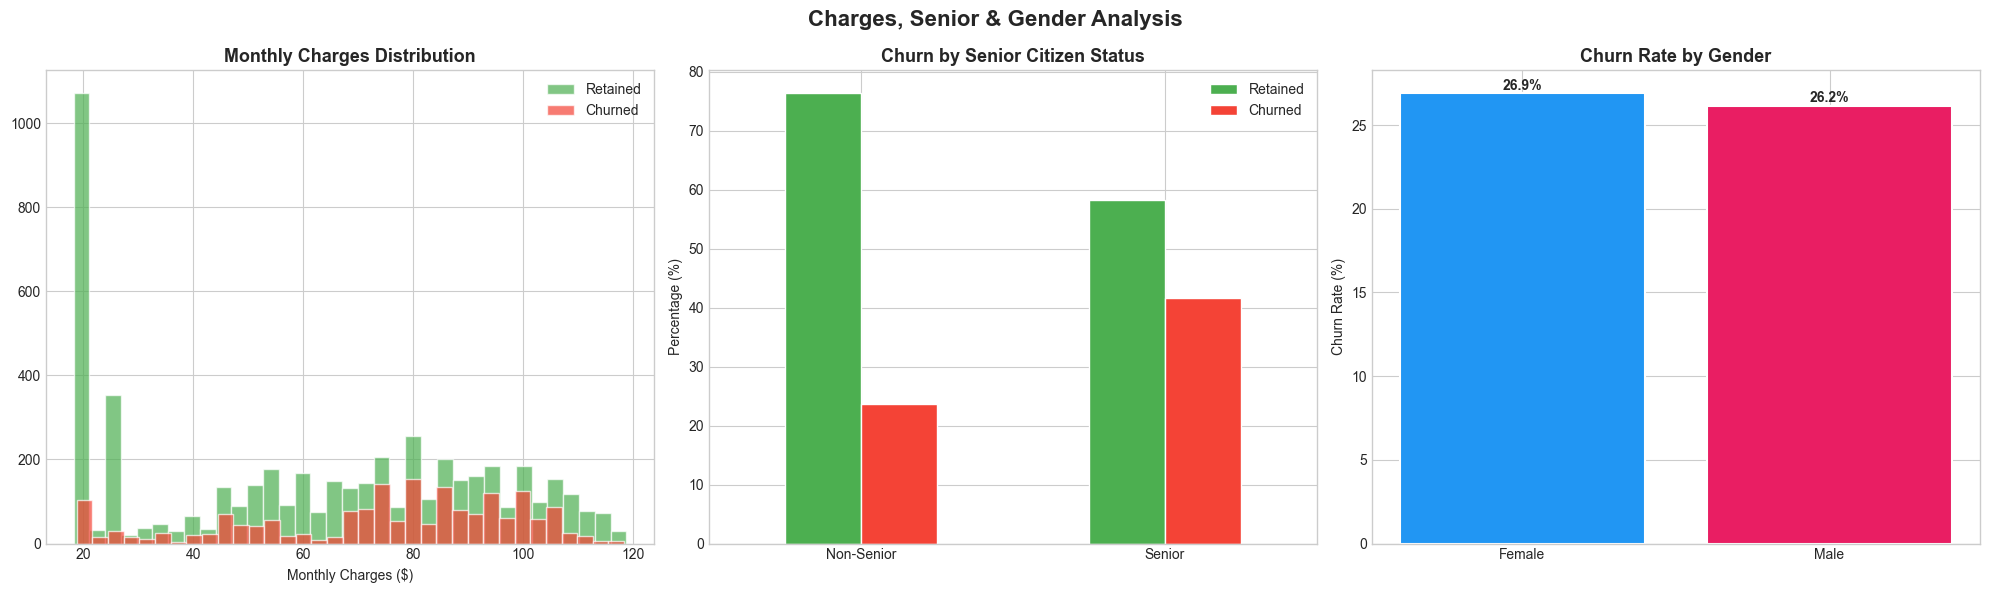

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Charges, Senior & Gender Analysis', fontsize=16, fontweight='bold')

axes[0].hist(df[df['Churn']==0]['MonthlyCharges'], bins=35, alpha=0.7, label='Retained', color='#4CAF50', edgecolor='white')
axes[0].hist(df[df['Churn']==1]['MonthlyCharges'], bins=35, alpha=0.7, label='Churned', color='#F44336', edgecolor='white')
axes[0].set_title('Monthly Charges Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)'); axes[0].legend()

sen = df.groupby(['SeniorCitizen','Churn']).size().unstack(fill_value=0)
sen_pct = sen.div(sen.sum(axis=1), axis=0)*100
sen_pct.index = ['Non-Senior','Senior']
sen_pct.plot(kind='bar', ax=axes[1], color=['#4CAF50','#F44336'], edgecolor='white')
axes[1].set_title('Churn by Senior Citizen Status', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)'); axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Retained','Churned'])

gen = df.groupby('gender')['Churn'].mean()*100
axes[2].bar(gen.index, gen.values, color=['#2196F3','#E91E63'], edgecolor='white', linewidth=1.5)
for i,(idx,v) in enumerate(gen.items()):
    axes[2].text(i, v+0.2, f'{v:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Churn Rate by Gender', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('02_charges_senior_gender.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

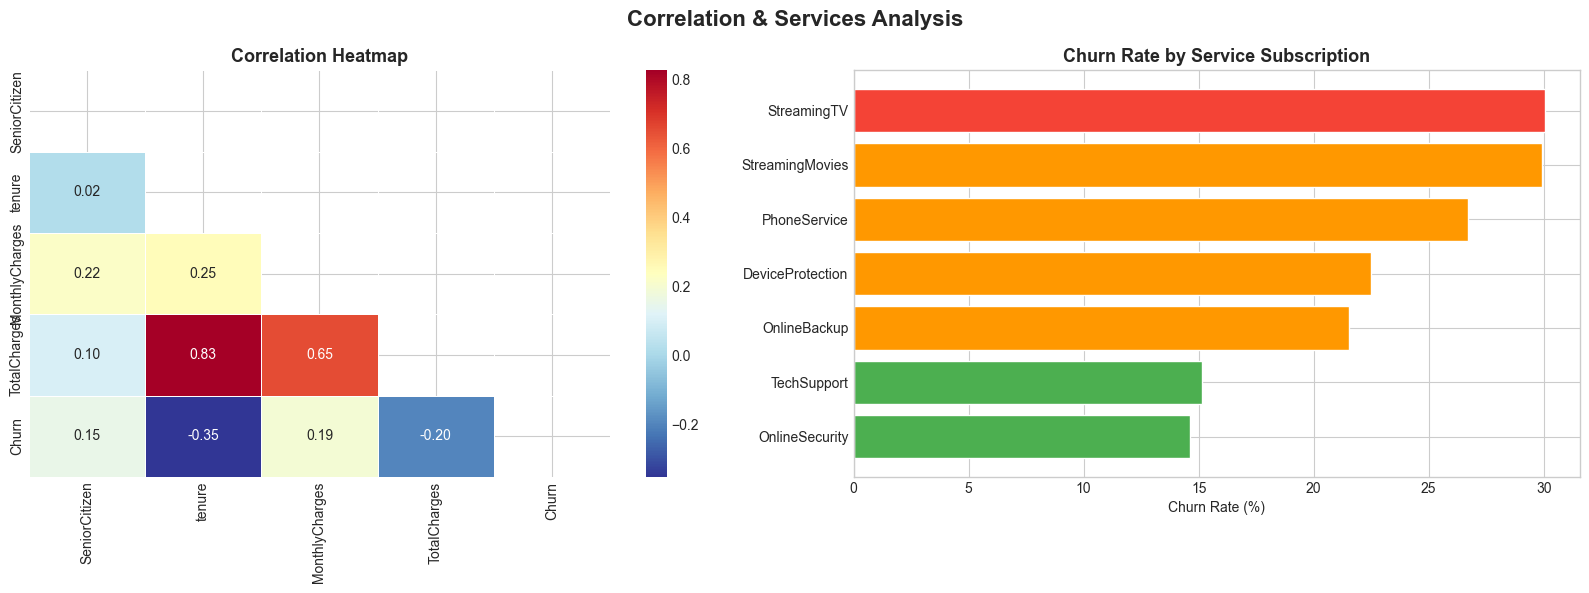

In [16]:
num_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges','Churn']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation & Services Analysis', fontsize=16, fontweight='bold')

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlBu_r', mask=mask, linewidths=0.5)
axes[0].set_title('Correlation Heatmap', fontsize=13, fontweight='bold')

svc_cols = ['PhoneService','OnlineSecurity','TechSupport','OnlineBackup','DeviceProtection','StreamingTV','StreamingMovies']
svc_churn = {c: df[df[c]=='Yes']['Churn'].mean()*100 for c in svc_cols}
svc_s = pd.Series(svc_churn).sort_values(ascending=False)
clrs = ['#F44336' if v>30 else '#FF9800' if v>20 else '#4CAF50' for v in svc_s.values]
axes[1].barh(svc_s.index[::-1], svc_s.values[::-1], color=clrs[::-1], edgecolor='white')
axes[1].set_title('Churn Rate by Service Subscription', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('03_correlation_services.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [17]:
df_feat = df.drop(columns=['customerID'])

df_feat['TenureGroup']          = pd.cut(df_feat['tenure'], bins=[0,12,24,48,72],
                                          labels=['0-1yr','1-2yr','2-4yr','4+yr'], include_lowest=True)
df_feat['ChargesPerTenure']     = (df_feat['TotalCharges'] / (df_feat['tenure']+1)).round(2)
df_feat['HighMonthlyCharge']    = (df_feat['MonthlyCharges'] > df_feat['MonthlyCharges'].quantile(0.75)).astype(int)
df_feat['HasSupport']           = ((df_feat['TechSupport']=='Yes') | (df_feat['OnlineSecurity']=='Yes')).astype(int)
df_feat['IsLongTenure']         = (df_feat['tenure'] > 24).astype(int)
df_feat['MonthlyToTotalRatio']  = (df_feat['MonthlyCharges'] / (df_feat['TotalCharges']+1)).round(4)
df_feat['NumStreamingServices'] = ((df_feat['StreamingTV']=='Yes').astype(int) + (df_feat['StreamingMovies']=='Yes').astype(int))
df_feat['NumProtectionServices']= ((df_feat['OnlineBackup']=='Yes').astype(int) + (df_feat['DeviceProtection']=='Yes').astype(int))

print(f'Features after engineering: {df_feat.shape[1]-1} + 1 target')
df_feat.head()

Features after engineering: 27 + 1 target


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,TenureGroup,ChargesPerTenure,HighMonthlyCharge,HasSupport,IsLongTenure,MonthlyToTotalRatio,NumStreamingServices,NumProtectionServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.85,0,0-1yr,14.92,0,0,0,0.9676,0,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,1889.50,0,2-4yr,53.99,0,1,1,0.0301,0,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,108.15,1,0-1yr,36.05,0,1,0,0.4934,0,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,1840.75,0,2-4yr,40.02,0,1,1,0.0230,0,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,151.65,1,0-1yr,50.55,0,0,0,0.4632,0,0


In [18]:
cat_cols = ['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService',
            'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV',
            'StreamingMovies','Contract','PaperlessBilling','PaymentMethod','TenureGroup']

le = LabelEncoder()
df_enc = df_feat.copy()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

imp = SimpleImputer(strategy='median')
X = pd.DataFrame(imp.fit_transform(X), columns=X.columns)

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Class   : {y.value_counts().to_dict()}')

X shape : (7043, 27)
y shape : (7043,)
Class   : {0: 5174, 1: 1869}


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Before SMOTE — Train: {X_train.shape}, Churn: {y_train.sum()} ({y_train.mean():.2%})')

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'After  SMOTE — Train: {X_train_sm.shape}, Churn: {y_train_sm.sum()} ({y_train_sm.mean():.2%})')

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

print(f'\nTest set : {X_test_sc.shape}, Churn rate: {y_test.mean():.2%}')

Before SMOTE — Train: (5634, 27), Churn: 1495 (26.54%)
After  SMOTE — Train: (8278, 27), Churn: 4139 (50.00%)

Test set : (1409, 27), Churn rate: 26.54%


In [20]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=8, random_state=42, class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVM'                 : SVC(probability=True, C=1.0, random_state=42, class_weight='balanced'),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Naive Bayes'         : GaussianNB(),
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results  = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train_sm)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:,1]
    pipe   = ImbPipeline([('smote', SMOTE(random_state=42, k_neighbors=5)),
                           ('scaler', StandardScaler()), ('model', model)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv_strat, scoring='roc_auc', n_jobs=-1)
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy':      accuracy_score(y_test, y_pred),
        'f1':            f1_score(y_test, y_pred),
        'roc_auc':       roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob),
        'cv_mean':       cv_auc.mean(),
        'cv_std':        cv_auc.std(),
    }
    print(f'{name:22s} | ROC-AUC={results[name]["roc_auc"]:.4f} | F1={results[name]["f1"]:.4f} | CV={results[name]["cv_mean"]:.4f}±{results[name]["cv_std"]:.4f}')

Logistic Regression    | ROC-AUC=0.8452 | F1=0.6202 | CV=0.8476±0.0119
Decision Tree          | ROC-AUC=0.8071 | F1=0.5758 | CV=0.8092±0.0173
Random Forest          | ROC-AUC=0.8386 | F1=0.6005 | CV=0.8432±0.0108
Extra Trees            | ROC-AUC=0.7953 | F1=0.5194 | CV=0.8071±0.0122
Gradient Boosting      | ROC-AUC=0.8385 | F1=0.5902 | CV=0.8419±0.0073
AdaBoost               | ROC-AUC=0.8411 | F1=0.6201 | CV=0.8429±0.0130
SVM                    | ROC-AUC=0.8209 | F1=0.6042 | CV=0.8239±0.0134
KNN                    | ROC-AUC=0.7737 | F1=0.5570 | CV=0.7808±0.0065
Naive Bayes            | ROC-AUC=0.8242 | F1=0.6043 | CV=0.8226±0.0122


In [21]:
results_df = pd.DataFrame([{
    'Model':           name,
    'Accuracy':        v['accuracy'],
    'F1_Score':        v['f1'],
    'ROC_AUC':         v['roc_auc'],
    'Avg_Precision':   v['avg_precision'],
    'CV_ROC_AUC_Mean': v['cv_mean'],
    'CV_ROC_AUC_Std':  v['cv_std'],
} for name,v in results.items()]).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

best_name  = results_df.iloc[0]['Model']
best_model = results[best_name]['model']
best_pred  = results[best_name]['y_pred']
best_prob  = results[best_name]['y_prob']

print(f'Best Model : {best_name}')
print(f'ROC-AUC    : {results_df.iloc[0]["ROC_AUC"]:.4f}')
print(f'F1 Score   : {results_df.iloc[0]["F1_Score"]:.4f}')
print(f'Accuracy   : {results_df.iloc[0]["Accuracy"]:.4f}')
results_df

Best Model : Logistic Regression
ROC-AUC    : 0.8452
F1 Score   : 0.6202
Accuracy   : 0.7410


,Model,Accuracy,F1_Score,ROC_AUC,Avg_Precision,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Logistic Regression,0.740951,0.620187,0.845214,0.660442,0.847585,0.011949
1,AdaBoost,0.799148,0.620134,0.841108,0.658529,0.842880,0.012992
2,Random Forest,0.774308,0.600503,0.838557,0.646537,0.843190,0.010772
3,Gradient Boosting,0.792051,0.590210,0.838456,0.652761,0.841947,0.007330
4,Naive Bayes,0.726757,0.604317,0.824183,0.633324,0.822570,0.012177
5,SVM,0.772179,0.604192,0.820853,0.623917,0.823875,0.013448
6,Decision Tree,0.763662,0.575796,0.807104,0.552705,0.809245,0.017329
7,Extra Trees,0.762243,0.519369,0.795341,0.571093,0.807111,0.012180
8,KNN,0.694109,0.557040,0.773664,0.498416,0.780773,0.006498


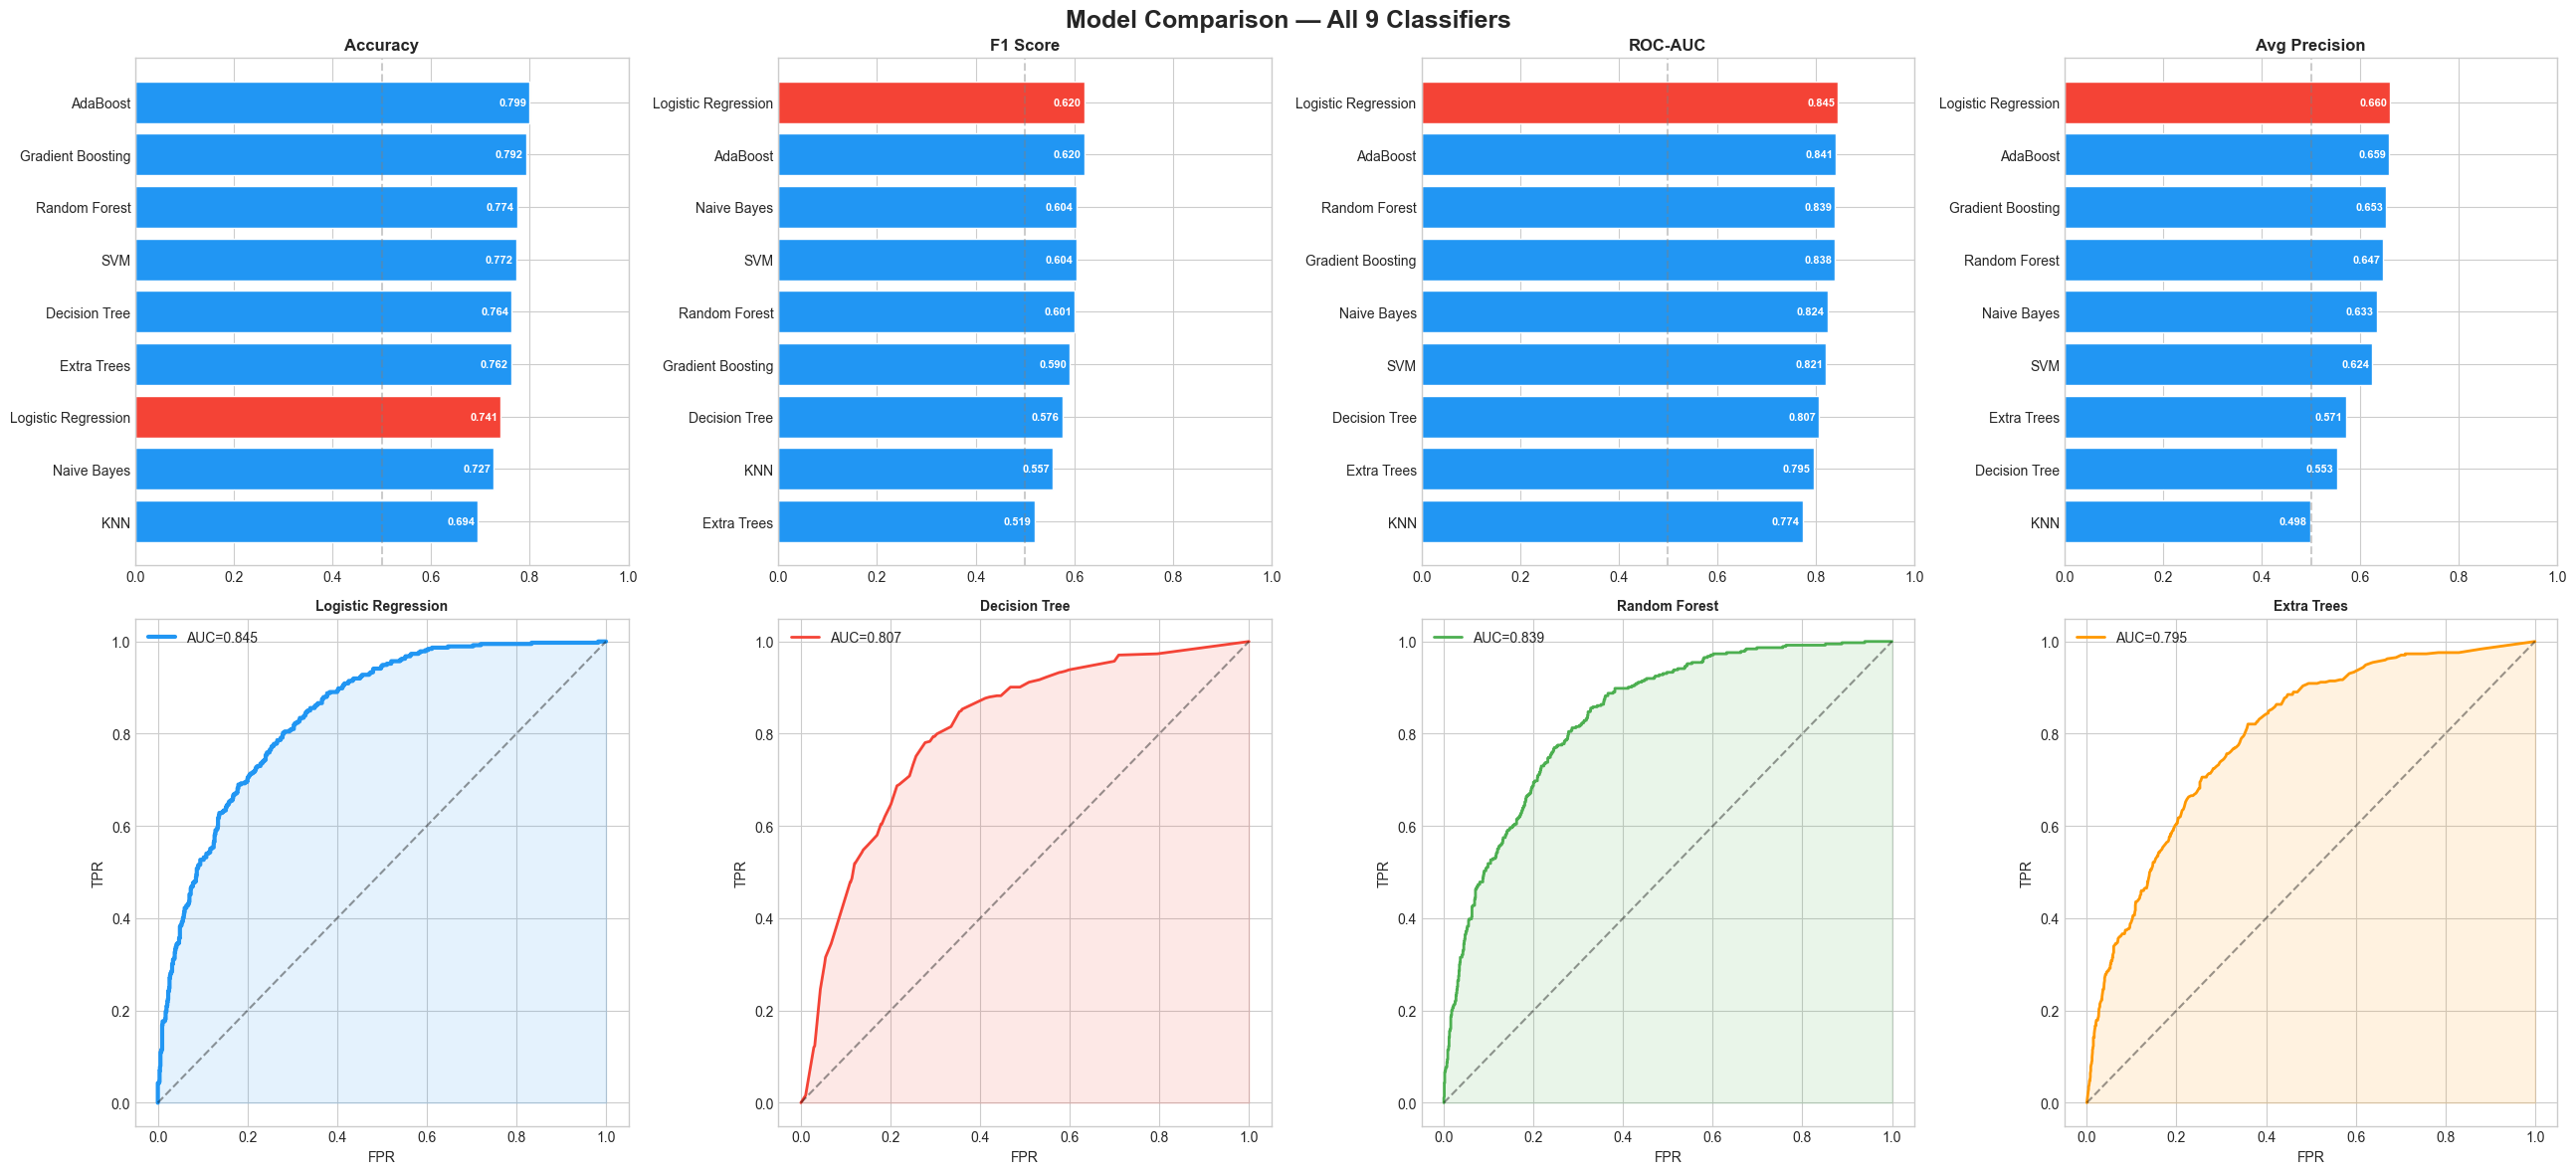

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(26, 12))
fig.suptitle('Model Comparison — All 9 Classifiers', fontsize=18, fontweight='bold')

metrics    = ['Accuracy','F1_Score','ROC_AUC','Avg_Precision']
met_labels = ['Accuracy','F1 Score','ROC-AUC','Avg Precision']
for i,(metric,label) in enumerate(zip(metrics,met_labels)):
    sdf  = results_df.sort_values(metric, ascending=True)
    clrs = ['#F44336' if n==best_name else '#2196F3' for n in sdf['Model']]
    bars = axes[0,i].barh(sdf['Model'], sdf[metric], color=clrs, edgecolor='white')
    for b,v in zip(bars,sdf[metric]):
        axes[0,i].text(b.get_width()-0.006, b.get_y()+b.get_height()/2,
                       f'{v:.3f}', va='center', ha='right', fontweight='bold', fontsize=8, color='white')
    axes[0,i].set_title(label, fontsize=12, fontweight='bold')
    axes[0,i].set_xlim(0,1.0); axes[0,i].axvline(0.5, color='gray', linestyle='--', alpha=0.4)

for i,(name,v) in enumerate(list(results.items())[:4]):
    fpr,tpr,_ = roc_curve(y_test, v['y_prob'])
    axes[1,i].plot(fpr,tpr,color=PAL[i],lw=3 if name==best_name else 2,label=f'AUC={v["roc_auc"]:.3f}')
    axes[1,i].plot([0,1],[0,1],'k--',alpha=0.4)
    axes[1,i].fill_between(fpr,tpr,alpha=0.12,color=PAL[i])
    axes[1,i].set_title(name,fontsize=10,fontweight='bold')
    axes[1,i].set_xlabel('FPR'); axes[1,i].set_ylabel('TPR'); axes[1,i].legend()

plt.tight_layout()
plt.savefig('04_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

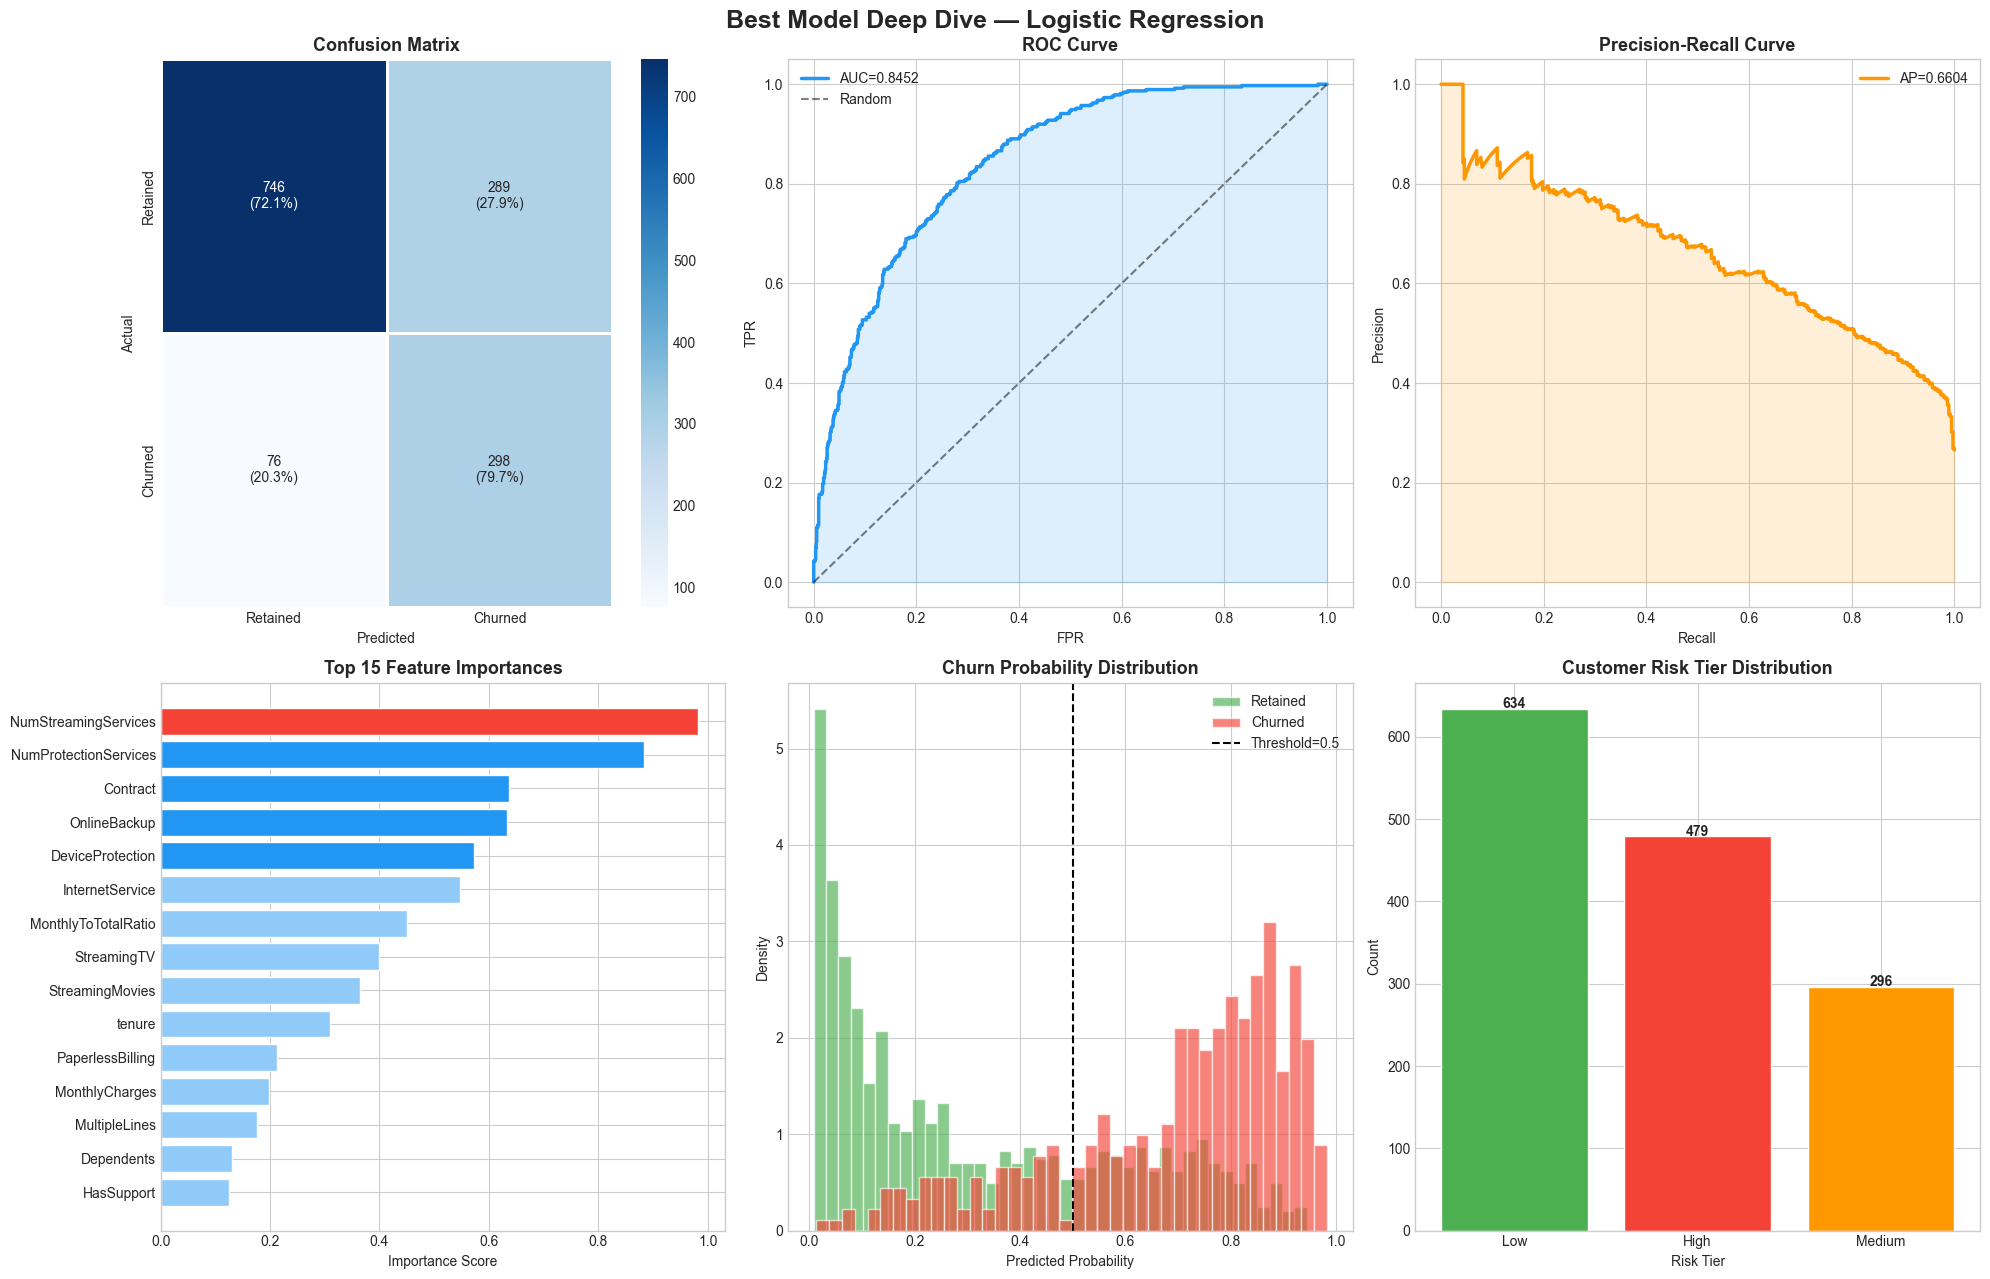

In [23]:
if hasattr(best_model,'feature_importances_'):
    feat_imp = pd.DataFrame({'Feature':X.columns,'Importance':best_model.feature_importances_})
elif hasattr(best_model,'coef_'):
    feat_imp = pd.DataFrame({'Feature':X.columns,'Importance':np.abs(best_model.coef_[0])})
else:
    feat_imp = pd.DataFrame({'Feature':X.columns,'Importance':np.ones(len(X.columns))})
feat_imp = feat_imp.sort_values('Importance',ascending=False).head(15).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle(f'Best Model Deep Dive — {best_name}', fontsize=18, fontweight='bold')

cm     = confusion_matrix(y_test, best_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True)*100
annot  = np.array([[f'{v}\n({p:.1f}%)' for v,p in zip(row,prow)] for row,prow in zip(cm,cm_pct)])
sns.heatmap(cm, annot=annot, fmt='', ax=axes[0,0], cmap='Blues',
            xticklabels=['Retained','Churned'], yticklabels=['Retained','Churned'],
            linewidths=1, linecolor='white')
axes[0,0].set_title('Confusion Matrix',fontsize=13,fontweight='bold')
axes[0,0].set_ylabel('Actual'); axes[0,0].set_xlabel('Predicted')

fpr,tpr,_ = roc_curve(y_test, best_prob)
axes[0,1].plot(fpr,tpr,color='#2196F3',lw=2.5,label=f'AUC={results[best_name]["roc_auc"]:.4f}')
axes[0,1].plot([0,1],[0,1],'k--',alpha=0.5,label='Random')
axes[0,1].fill_between(fpr,tpr,alpha=0.15,color='#2196F3')
axes[0,1].set_title('ROC Curve',fontsize=13,fontweight='bold')
axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR'); axes[0,1].legend()

prec,rec,_ = precision_recall_curve(y_test, best_prob)
axes[0,2].plot(rec,prec,color='#FF9800',lw=2.5,label=f'AP={results[best_name]["avg_precision"]:.4f}')
axes[0,2].fill_between(rec,prec,alpha=0.15,color='#FF9800')
axes[0,2].set_title('Precision-Recall Curve',fontsize=13,fontweight='bold')
axes[0,2].set_xlabel('Recall'); axes[0,2].set_ylabel('Precision'); axes[0,2].legend()

clrs_f = ['#F44336' if i==0 else '#2196F3' if i<5 else '#90CAF9' for i in range(len(feat_imp))]
axes[1,0].barh(feat_imp['Feature'][::-1],feat_imp['Importance'][::-1],color=clrs_f[::-1],edgecolor='white')
axes[1,0].set_title('Top 15 Feature Importances',fontsize=13,fontweight='bold')
axes[1,0].set_xlabel('Importance Score')

axes[1,1].hist(best_prob[y_test.values==0],bins=40,alpha=0.65,label='Retained',color='#4CAF50',density=True,edgecolor='white')
axes[1,1].hist(best_prob[y_test.values==1],bins=40,alpha=0.65,label='Churned',color='#F44336',density=True,edgecolor='white')
axes[1,1].axvline(0.5,color='black',linestyle='--',lw=1.5,label='Threshold=0.5')
axes[1,1].set_title('Churn Probability Distribution',fontsize=13,fontweight='bold')
axes[1,1].set_xlabel('Predicted Probability'); axes[1,1].set_ylabel('Density'); axes[1,1].legend()

risk = pd.cut(best_prob, bins=[0,0.3,0.6,1.0], labels=['Low','Medium','High'])
rc   = pd.Series(risk).value_counts()
rcol = {'Low':'#4CAF50','Medium':'#FF9800','High':'#F44336'}
b4   = axes[1,2].bar(rc.index.astype(str),rc.values,color=[rcol.get(str(k),'#2196F3') for k in rc.index],edgecolor='white')
for b,v in zip(b4,rc.values):
    axes[1,2].text(b.get_x()+b.get_width()/2,b.get_height()+1,f'{v}',ha='center',fontweight='bold')
axes[1,2].set_title('Customer Risk Tier Distribution',fontsize=13,fontweight='bold')
axes[1,2].set_xlabel('Risk Tier'); axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('05_best_model_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

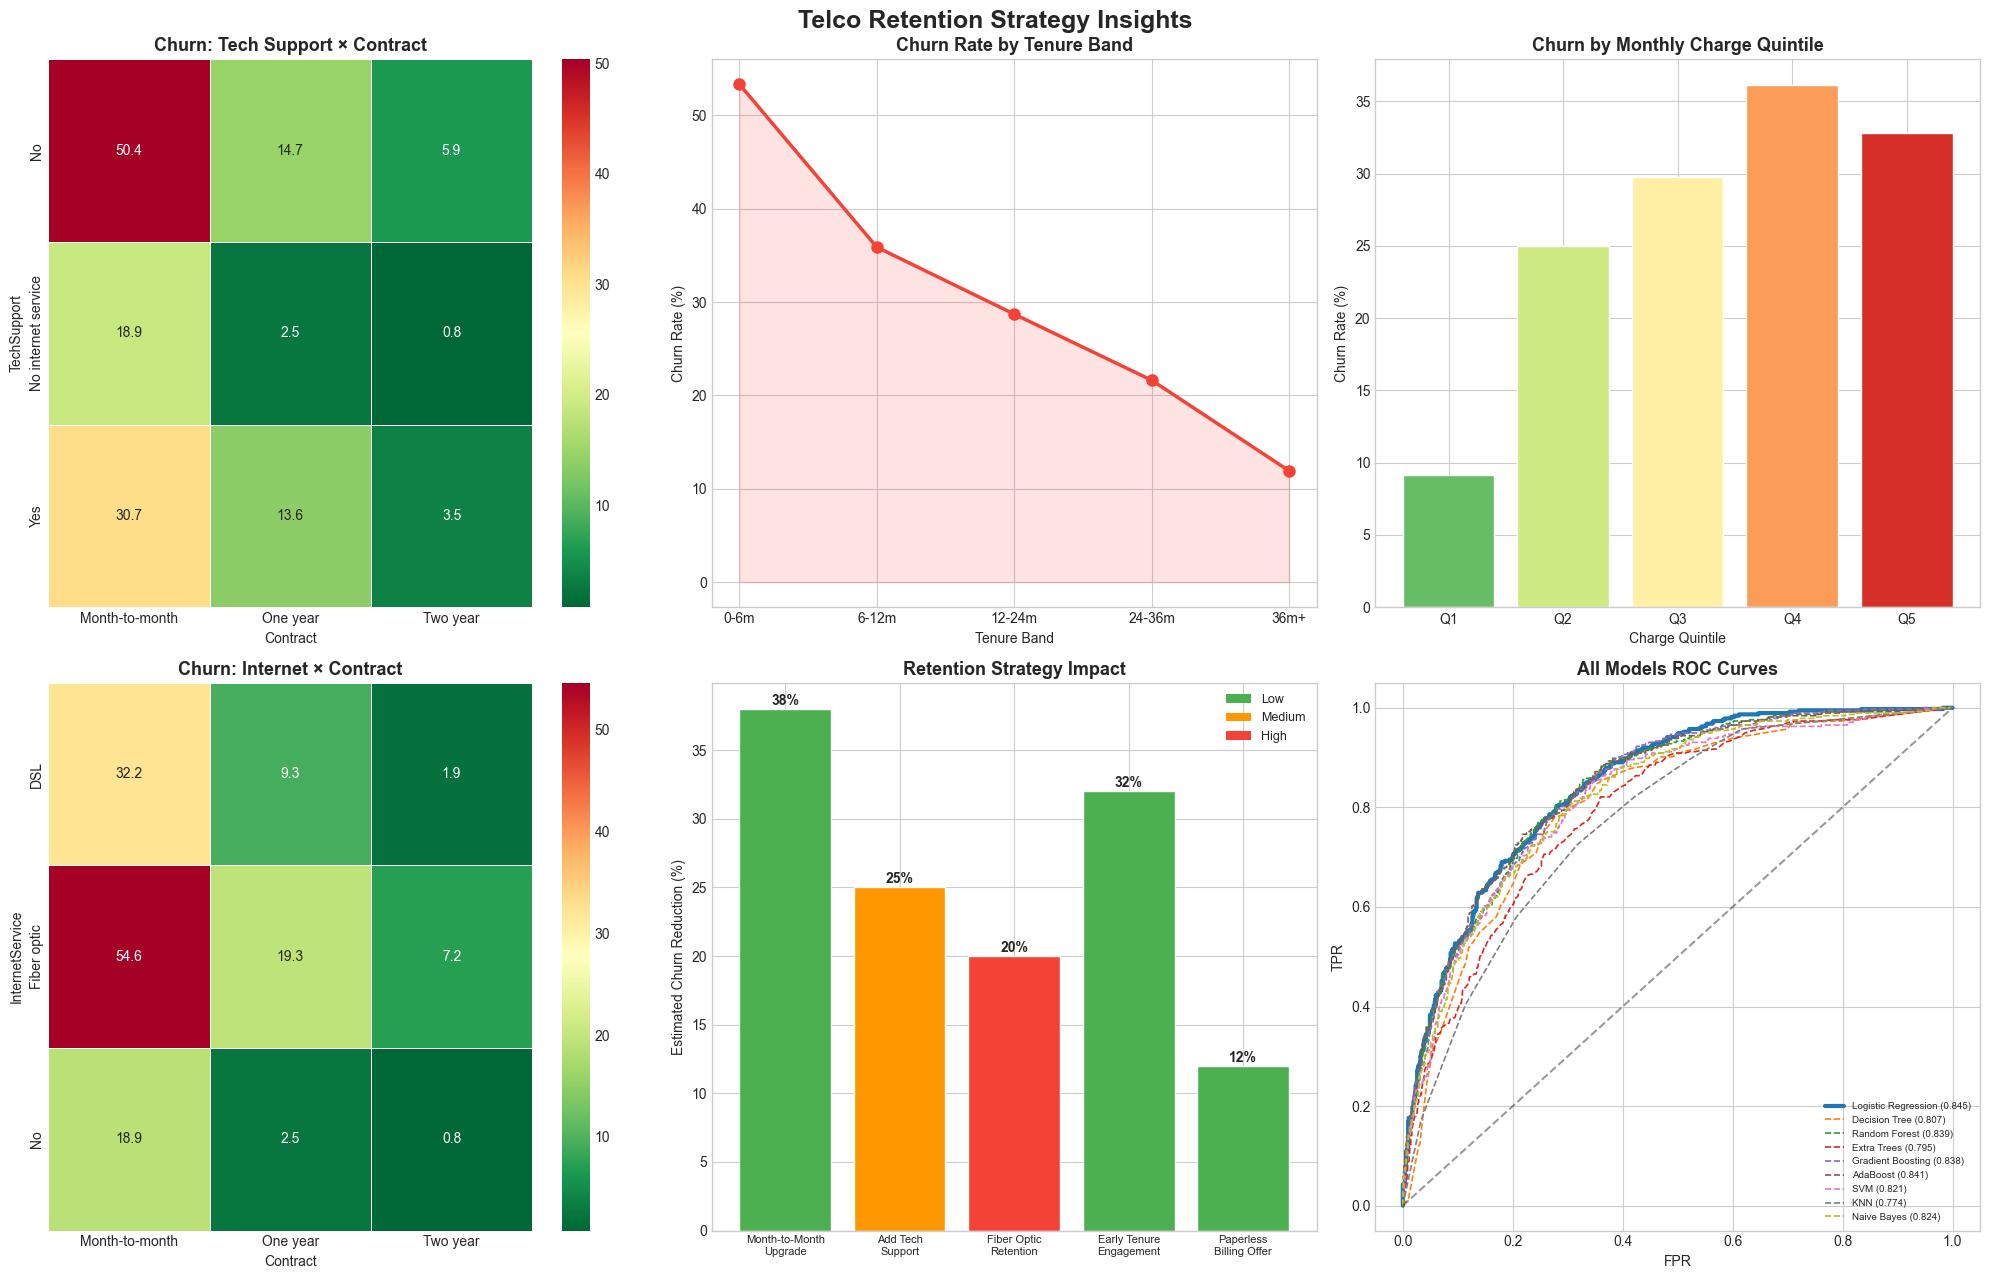

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle('Telco Retention Strategy Insights', fontsize=18, fontweight='bold')

cont_tech = df.pivot_table(values='Churn', index='TechSupport', columns='Contract', aggfunc='mean')*100
sns.heatmap(cont_tech, ax=axes[0,0], cmap='RdYlGn_r', annot=True, fmt='.1f', linewidths=0.5)
axes[0,0].set_title('Churn: Tech Support × Contract', fontsize=13, fontweight='bold')

tenure_bins = pd.cut(df['tenure'], bins=[0,6,12,24,36,72], labels=['0-6m','6-12m','12-24m','24-36m','36m+'])
ten_churn   = df.groupby(tenure_bins)['Churn'].mean()*100
axes[0,1].plot(range(len(ten_churn)), ten_churn.values, 'o-', color='#F44336', lw=2.5, ms=8)
axes[0,1].fill_between(range(len(ten_churn)), ten_churn.values, alpha=0.15, color='#F44336')
axes[0,1].set_xticks(range(len(ten_churn))); axes[0,1].set_xticklabels(ten_churn.index)
axes[0,1].set_title('Churn Rate by Tenure Band', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Tenure Band'); axes[0,1].set_ylabel('Churn Rate (%)')

charge_q = pd.qcut(df['MonthlyCharges'], q=5)
cq_churn = df.groupby(charge_q)['Churn'].mean()*100
axes[0,2].bar(range(len(cq_churn)), cq_churn.values,
              color=plt.cm.RdYlGn_r(np.linspace(0.2,0.9,len(cq_churn))), edgecolor='white')
axes[0,2].set_xticks(range(len(cq_churn))); axes[0,2].set_xticklabels([f'Q{i+1}' for i in range(len(cq_churn))])
axes[0,2].set_title('Churn by Monthly Charge Quintile', fontsize=13, fontweight='bold')
axes[0,2].set_ylabel('Churn Rate (%)'); axes[0,2].set_xlabel('Charge Quintile')

inet_cont = df.pivot_table(values='Churn', index='InternetService', columns='Contract', aggfunc='mean')*100
sns.heatmap(inet_cont, ax=axes[1,0], cmap='RdYlGn_r', annot=True, fmt='.1f', linewidths=0.5)
axes[1,0].set_title('Churn: Internet × Contract', fontsize=13, fontweight='bold')

strat = pd.DataFrame({
    'Intervention': ['Month-to-Month\nUpgrade','Add Tech\nSupport','Fiber Optic\nRetention','Early Tenure\nEngagement','Paperless\nBilling Offer'],
    'Reduction':    [38, 25, 20, 32, 12],
    'Cost':         ['Low','Medium','High','Low','Low']
})
ccol = {'Low':'#4CAF50','Medium':'#FF9800','High':'#F44336'}
bs   = axes[1,1].bar(range(len(strat)), strat['Reduction'],
                      color=[ccol[c] for c in strat['Cost']], edgecolor='white')
for b,v in zip(bs, strat['Reduction']):
    axes[1,1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v}%', ha='center', fontweight='bold')
axes[1,1].set_xticks(range(len(strat))); axes[1,1].set_xticklabels(strat['Intervention'], fontsize=8)
axes[1,1].set_title('Retention Strategy Impact', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Estimated Churn Reduction (%)')
from matplotlib.patches import Patch
axes[1,1].legend(handles=[Patch(facecolor='#4CAF50',label='Low'),
                            Patch(facecolor='#FF9800',label='Medium'),
                            Patch(facecolor='#F44336',label='High')], fontsize=9)

for name,v in results.items():
    fpr_m,tpr_m,_ = roc_curve(y_test, v['y_prob'])
    axes[1,2].plot(fpr_m,tpr_m,
                   lw=3 if name==best_name else 1.2,
                   linestyle='-' if name==best_name else '--',
                   label=f'{name} ({v["roc_auc"]:.3f})')
axes[1,2].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1,2].set_title('All Models ROC Curves', fontsize=13, fontweight='bold')
axes[1,2].set_xlabel('FPR'); axes[1,2].set_ylabel('TPR'); axes[1,2].legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('06_retention_insights.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [25]:
X_out = X_test.copy().reset_index(drop=True)
X_out['Churn_Actual']      = y_test.values
X_out['Churn_Predicted']   = best_pred
X_out['Churn_Probability'] = best_prob.round(4)
X_out['Risk_Tier']         = pd.cut(best_prob, bins=[0,0.3,0.6,1.0], labels=['Low','Medium','High'])

results_df.to_csv('model_comparison.csv', index=False)
X_out.to_csv('churn_risk_scores.csv', index=False)
feat_imp.to_csv('feature_importance.csv', index=False)
pd.DataFrame(classification_report(y_test,best_pred,output_dict=True)).T.reset_index().rename(columns={'index':'Class'}).to_csv('classification_report.csv', index=False)

print('Saved: model_comparison.csv')
print('Saved: churn_risk_scores.csv')
print('Saved: feature_importance.csv')
print('Saved: classification_report.csv')

Saved: model_comparison.csv
Saved: churn_risk_scores.csv
Saved: feature_importance.csv
Saved: classification_report.csv


In [26]:
print('=' * 55)
print('  TELCO CUSTOMER CHURN — FINAL SUMMARY')
print('=' * 55)
print(f'  Dataset          : WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'  Total Customers  : {len(df):,}')
print(f'  Churn Rate       : {df["Churn"].mean():.2%}')
print(f'  SMOTE Applied    : Yes — balanced training set 50/50')
print(f'  Models Trained   : {len(models)}')
print(f'  Best Model       : {best_name}')
print(f'  ROC-AUC          : {results[best_name]["roc_auc"]:.4f}')
print(f'  F1 Score         : {results[best_name]["f1"]:.4f}')
print(f'  Accuracy         : {results[best_name]["accuracy"]:.4f}')
print(f'  High Risk Cust.  : {(best_prob > 0.6).sum():,} / {len(best_prob):,} test customers')
print('=' * 55)
print('  Top 5 Churn Drivers:')
for i,row in feat_imp.head(5).iterrows():
    print(f'    {i+1}. {row["Feature"]:25s} {row["Importance"]:.4f}')
print('=' * 55)

  TELCO CUSTOMER CHURN — FINAL SUMMARY
  Dataset          : WA_Fn-UseC_-Telco-Customer-Churn.csv
  Total Customers  : 7,043
  Churn Rate       : 26.54%
  SMOTE Applied    : Yes — balanced training set 50/50
  Models Trained   : 9
  Best Model       : Logistic Regression
  ROC-AUC          : 0.8452
  F1 Score         : 0.6202
  Accuracy         : 0.7410
  High Risk Cust.  : 479 / 1,409 test customers
  Top 5 Churn Drivers:
    1. NumStreamingServices      0.9833
    2. NumProtectionServices     0.8829
    3. Contract                  0.6377
    4. OnlineBackup              0.6326
    5. DeviceProtection          0.5719
